In [239]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization


# Загрузка данных

Загружаем файл Students Social Media Addiction.csv

In [240]:
df = pd.read_csv('Students Social Media Addiction.csv')

Выводим 10 первых записей

In [360]:
df.head(10)

,Student_ID,Age,Gender,Avg_Daily_Usage_Hours,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score,Most_Used_Platform_Instagram,...,Country_Uzbekistan,Country_Vatican City,Country_Venezuela,Country_Vietnam,Country_Yemen,Academic_Level_High School,Academic_Level_Undergraduate,Relationship_Status_In Relationship,Relationship_Status_Single,Is_Addicted
0,1,-1.186915,0,0.223857,1,-0.327638,-0.205520,0.157063,0.985550,True,...,False,False,False,False,False,False,True,True,False,1
1,2,0.958662,1,-2.243309,0,0.560423,1.605628,-2.976790,-2.166958,False,...,False,False,False,False,False,False,False,False,True,0
2,3,-0.471723,0,0.860545,1,-1.659730,-1.111095,1.201681,1.616052,False,...,False,False,False,False,False,False,True,False,False,1
3,4,-1.902108,1,-1.527035,0,0.116393,0.700054,-1.932172,-1.536456,False,...,False,False,False,False,False,True,False,False,True,0
4,5,0.243470,1,-0.333245,1,-0.771668,-0.205520,-0.887554,0.355048,False,...,False,False,False,False,False,False,False,True,False,0
5,6,-1.186915,0,1.815577,1,-2.103760,-2.016669,2.246298,1.616052,True,...,False,False,False,False,False,False,True,False,False,1
6,7,1.673855,1,-2.720825,0,1.004454,2.511203,-2.976790,-2.797459,False,...,False,False,False,False,False,False,False,False,True,0
7,8,-0.471723,0,0.701373,1,-0.771668,-0.205520,-0.887554,0.985550,False,...,False,False,False,False,False,False,True,True,False,1
8,9,-1.902108,1,-0.731175,0,-0.327638,0.700054,-1.932172,-0.905955,False,...,False,False,False,False,False,True,False,False,True,0
9,10,0.243470,0,-1.288277,0,0.116393,0.700054,-1.932172,-1.536456,True,...,False,False,False,False,False,False,False,True,False,0


# Описание данных

### Признаки:
- Age - возраст ученика;
- Gender - пол студента;
- Academic_Level - уровень образования (школа, колледж, университет и т.д.);
- Country - страна студента;
- Avg_Daily_Usage_Hours - уровень образования (школа, колледж, университет и т.д.);
- Most_Used_Platform - больше всего использовали социальные сети;
- Affects_Academic_Performance - влияют ли социальные сети на учёбу (Да/Нет);
- Sleep_Hours_Per_Night - среднее количество часов сна за ночь;
- Mental_Health_Score - балл, указывающий на психическое состояние;
- Relationship_Status - статус отношений;
- Conflicts_Over_Social_Media - конфликты в соцсетях.

### Целевая переменная:
Addicted_Score - результат зависимости

In [242]:
df.shape

(705, 13)

In [243]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

Посмотрели информацию и выяснили что всего 705 строк и 13 признаков

In [244]:
print("Пропущенные значения")
df.isnull().sum()

Пропущенные значения


Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

In [305]:
print("Дубликаты")
df.duplicated().sum()

Дубликаты


0

Пропусков и дубликатов нет

In [246]:
df = df.drop_duplicates()

In [247]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


# Кодирование признаков

In [248]:
df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})

In [249]:
df["Affects_Academic_Performance"] = df["Affects_Academic_Performance"].map({"No": 0, "Yes": 1})

Перевели признаки Gender и Affects_Academic_Performance в бинарное значение где 'Female':0 и 'Male':1 , 'No':0 и 'Yes':1

# Категориальные признаки

In [250]:
categorical_cols = [
    "Most_Used_Platform",
    "Country",
    "Academic_Level",
    "Relationship_Status"
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [251]:
df["Is_Addicted"] = (df["Addicted_Score"] > 7).astype(int)


# Масштабирование числовых данных

In [252]:
num_cols = [
    "Age",
    "Avg_Daily_Usage_Hours",
    "Sleep_Hours_Per_Night",
    "Mental_Health_Score",
    "Conflicts_Over_Social_Media",
    "Addicted_Score"
]

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


# Разведочный анализ данных

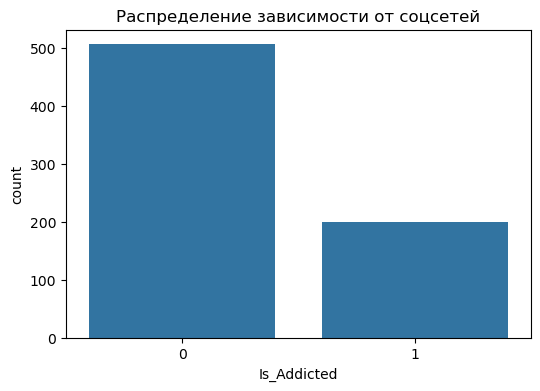

In [380]:
plt.figure(figsize=(6,4))
sns.countplot(x="Is_Addicted", data=df)
plt.title("Распределение зависимости от соцсетей")
plt.show()

большинство людей не зависимы от соцсетей

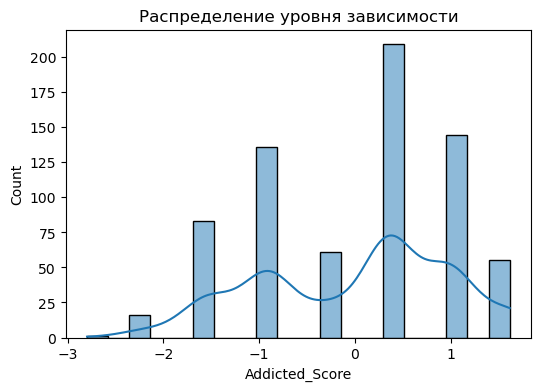

In [374]:
plt.figure(figsize=(6,4))
sns.histplot(df["Addicted_Score"], bins=20, kde=True)
plt.title("Распределение уровня зависимости")
plt.show()

Большинство студентов имеют средний уровень зависимости

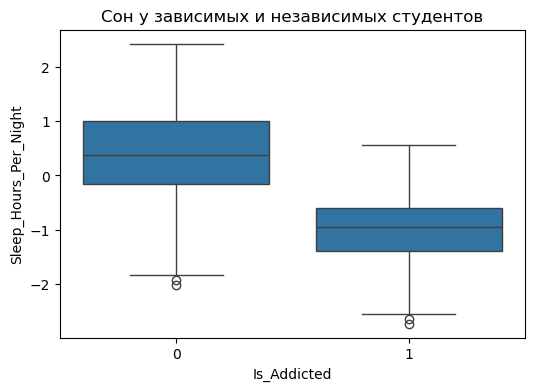

In [256]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Is_Addicted",
    y="Sleep_Hours_Per_Night",
    data=df
)
plt.title("Сон у зависимых и незавиcимых студентов")
plt.show()


независимые люди спят дольше чем зависимые

## Зависимые студенты спят меньше

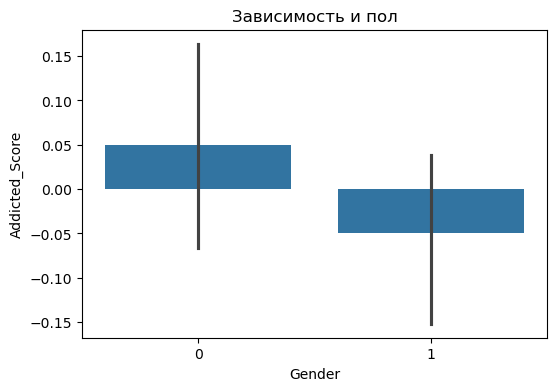

In [257]:
plt.figure(figsize=(6,4))
sns.barplot(
    x="Gender",
    y="Addicted_Score",
    data=df
)
plt.title("Зависимость и пол")
plt.show()


У женщин зависимость немного выше

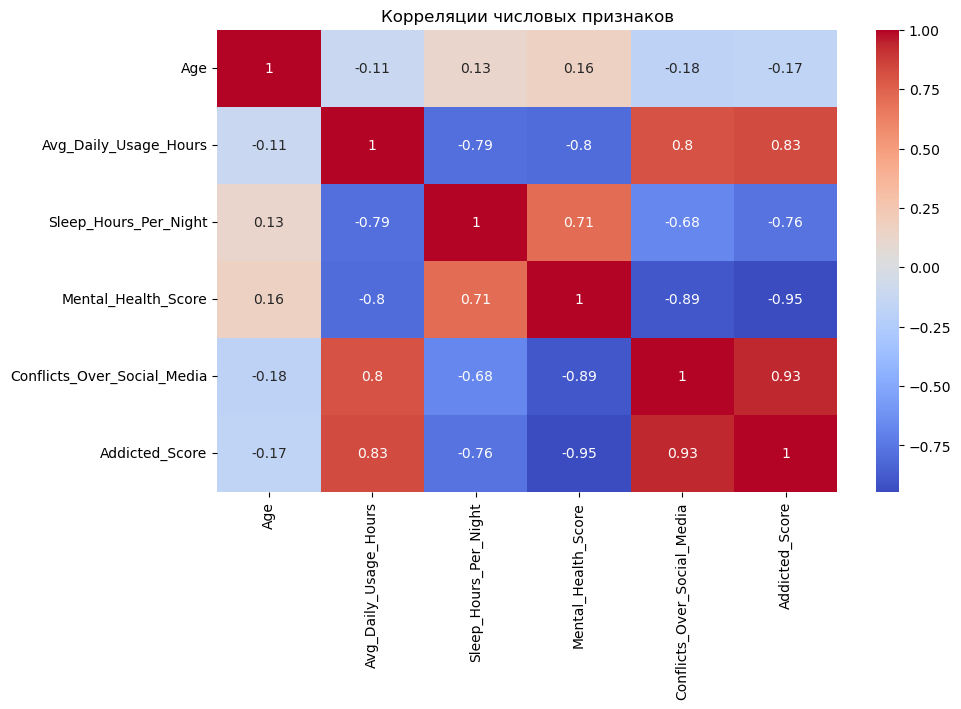

In [258]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Корреляции числовых признаков")
plt.show()


- Чем больше зависимость, тем хуже психологическое состояние
- Чем больше зависимость, тем больше конфликтов из-за соцсетей
- Чем больше времени человек проводит в соцсетях, тем выше зависимость
- Чем больше времени человек проводит в соцсетях, тем меньше сна

In [259]:
X = df.drop("Is_Addicted", axis=1)
y = df["Is_Addicted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Логистическая регрессия

In [260]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

accuracy_score(y_test, y_pred), f1_score(y_test, y_pred), roc_auc_score(y_test, y_prob)


(0.9787234042553191, 0.9620253164556962, 0.998019801980198)

# Random Forest

In [402]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

accuracy_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf), roc_auc_score(y_test, y_prob_rf)


(0.9858156028368794, 0.975, 0.9997524752475249)

# Важность признаков

In [262]:
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)


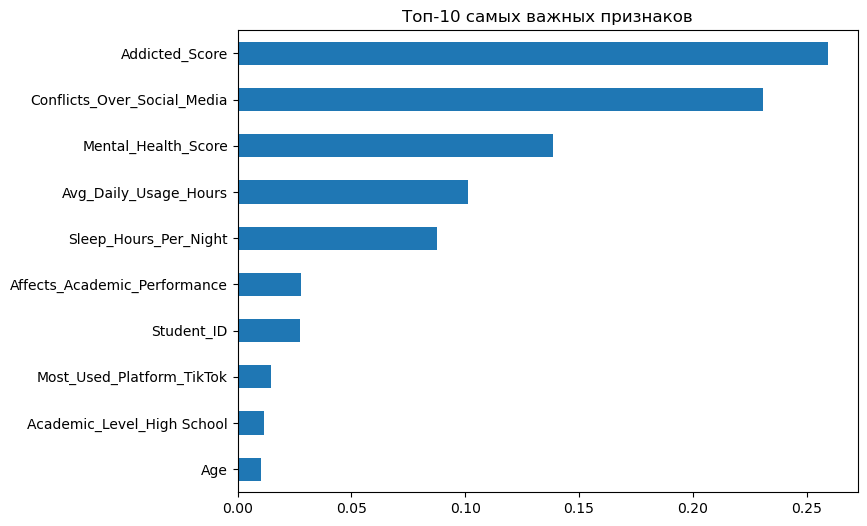

In [263]:
plt.figure(figsize=(8,6))
importances.head(10).plot(kind="barh")
plt.title("Топ-10 самых важных признаков")
plt.gca().invert_yaxis()
plt.show()


Важные признаки: уровень зависимости, конфликты из-зи соцсетей, ментальное здоровье, время использования, время сна

# Нейронная сеть

In [332]:
X = df.drop("Is_Addicted", axis=1)
y = df["Is_Addicted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [334]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])


In [336]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)


In [338]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5
)


In [340]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.5211 - auc: 0.4997 - loss: 0.7964 - val_accuracy: 0.7434 - val_auc: 0.4575 - val_loss: 0.7310 - learning_rate: 0.0010
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6984 - auc: 0.6324 - loss: 0.6431 - val_accuracy: 0.7434 - val_auc: 0.6775 - val_loss: 0.5581 - learning_rate: 0.0010
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7517 - auc: 0.7285 - loss: 0.5727 - val_accuracy: 0.7434 - val_auc: 0.6936 - val_loss: 0.5377 - learning_rate: 0.0010
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7716 - auc: 0.7454 - loss: 0.5147 - val_accuracy: 0.7434 - val_auc: 0.8651 - val_loss: 0.5137 - learning_rate: 0.0010
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7849 - auc: 0.7865 - loss: 0.4898 - val_accuracy: 0.8319 - val_auc: 0.9452 - val_loss: 0.5020 - learning_rate: 0.0010
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8315 - auc: 0

In [341]:
y_prob_nn = model.predict(X_test).ravel()
y_pred_nn = (y_prob_nn > 0.5).astype(int)

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("F1-score:", f1_score(y_test, y_pred_nn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nn))


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000021FCB9FE3E0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step
Accuracy: 0.8297872340425532
F1-score: 0.5714285714285714
ROC-AUC: 0.828960396039604


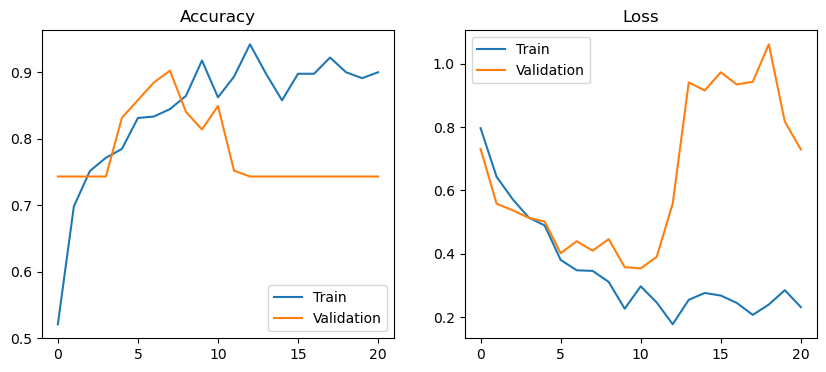

In [342]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.show()


Модель переобучается. Она становится все лучше и лучше подстраивается под конкретные примеры из обучающего набора, но ее способность делать правильные прогнозы на новых данных перестала расти и даже начала ухудшаться

# Сравнение лучших моделей

In [355]:
# Логистическая регрессия
log_acc = accuracy_score(y_test, log_reg.predict(X_test))
log_f1 = f1_score(y_test, log_reg.predict(X_test))
log_auc = roc_auc_score(y_test, log_reg.predict_proba(X_test)[:,1])

# Random Forest
rf_acc = accuracy_score(y_test, rf.predict(X_test))
rf_f1 = f1_score(y_test, rf.predict(X_test))
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

# Нейросеть
y_prob_nn = model.predict(X_test).ravel()
y_pred_nn = (y_prob_nn > 0.5).astype(int)
nn_acc = accuracy_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn)
nn_auc = roc_auc_score(y_test, y_prob_nn)

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Neural Network"],
    "Accuracy": [log_acc, rf_acc, nn_acc],
    "F1-score": [log_f1, rf_f1, nn_f1],
    "ROC-AUC": [log_auc, rf_auc, nn_auc]
})
results


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


,Model,Accuracy,F1-score,ROC-AUC
0,Logistic Regression,0.978723,0.962025,0.998020
1,Random Forest,0.985816,0.975000,0.999752
2,Neural Network,0.829787,0.571429,0.828960


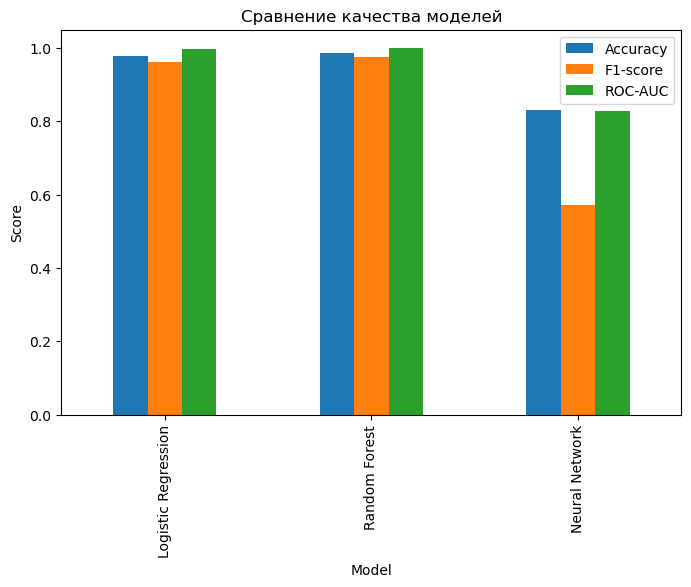

In [356]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(8,5),
    title="Сравнение качества моделей"
)
plt.ylabel("Score")
plt.show()

# Вывод

Лучший результат показала модель Random Forest. Нейроная сеть справилась хужеиз-за ограниченого обьема данных. Нейронная сеть продемонстрировала способность обучаться и выявлять закономерности